<a href="https://colab.research.google.com/github/replyeshab/CineAI-AI-Based-Hybrid-Recommendation-System/blob/main/movie_recommendation_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Loading

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
DATASET_PATH = "/content/drive/MyDrive/ml-32m/ml-32m"

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [16]:
movies = pd.read_csv(DATASET_PATH + "/" + "movies.csv")
ratings = pd.read_csv(DATASET_PATH + "/" + "ratings.csv")
tags = pd.read_csv(DATASET_PATH + "/" + "tags.csv")
links = pd.read_csv(DATASET_PATH + "/" + "links.csv")

In [8]:
print("Movies :", movies.shape)
print("Ratings:", ratings.shape)
print("Tags :", tags.shape)
print("Links :", links.shape)

NameError: name 'movies' is not defined

In [10]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [11]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [12]:
tags.head()

,userId,movieId,tag,timestamp
0,22,26479,Kevin Kline,1583038886
1,22,79592,misogyny,1581476297
2,22,247150,acrophobia,1622483469
3,34,2174,music,1249808064
4,34,2174,weird,1249808102


In [13]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [14]:
movies.info()
ratings.info()
tags.info()
links.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  87585 non-null  int64 
 1   title    87585 non-null  object
 2   genres   87585 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.0+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000204 entries, 0 to 32000203
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 976.6 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000072 entries, 0 to 2000071
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   userId     int64 
 1   movieId    int64 
 2   tag        object
 3   timestamp  int64 
dtypes: int64(3), object(1)
memory usage: 61.0+ MB
<class 'pandas.core.frame.DataFrame'>
RangeInd

## Data Preprocessing

In [15]:
print("="*50)
print("Movies")
print(movies.isnull().sum())

print("="*50)
print("Ratings")
print(ratings.isnull().sum())

print("="*50)
print("Tags")
print(tags.isnull().sum())

print("="*50)
print("Links")
print(links.isnull().sum())

Movies
movieId    0
title      0
genres     0
dtype: int64
Ratings
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
Tags
userId        0
movieId       0
tag          17
timestamp     0
dtype: int64
Links
movieId      0
imdbId       0
tmdbId     124
dtype: int64


In [16]:
print("Duplicate Movies :", movies.duplicated().sum())
print("Duplicate Ratings :", ratings.duplicated().sum())
print("Duplicate Tags :", tags.duplicated().sum())
print("Duplicate Links :", links.duplicated().sum())

Duplicate Movies : 0
Duplicate Ratings : 0
Duplicate Tags : 0
Duplicate Links : 0


In [17]:
print("Unique Users")
ratings.userId.nunique()

Unique Users


200948

In [18]:
print("Unique Movies")
ratings.movieId.nunique()

Unique Movies


84432

In [19]:
ratings.rating.describe()

,rating
count,3.200020e+07
mean,3.540396e+00
std,1.058986e+00
min,5.000000e-01
25%,3.000000e+00
50%,3.500000e+00
75%,4.000000e+00
max,5.000000e+00


In [20]:
sorted(ratings.rating.unique())

[np.float64(0.5),
 np.float64(1.0),
 np.float64(1.5),
 np.float64(2.0),
 np.float64(2.5),
 np.float64(3.0),
 np.float64(3.5),
 np.float64(4.0),
 np.float64(4.5),
 np.float64(5.0)]

In [21]:
tags = tags.dropna(subset=["tag"])

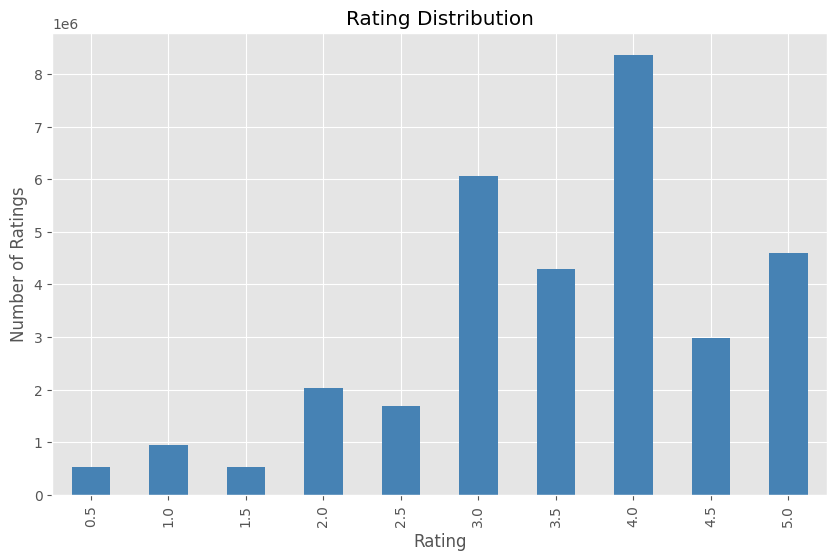

In [22]:
plt.figure(figsize=(10,6))

ratings["rating"].value_counts().sort_index().plot(
    kind="bar",
    color="steelblue"
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

plt.show()

In [25]:
movie_rating_counts = ratings.groupby("movieId").size()

movie_rating_counts.describe()

,0
count,84432.000000
mean,379.005638
std,2592.439791
min,1.000000
25%,2.000000
50%,5.000000
75%,25.000000
max,102929.000000


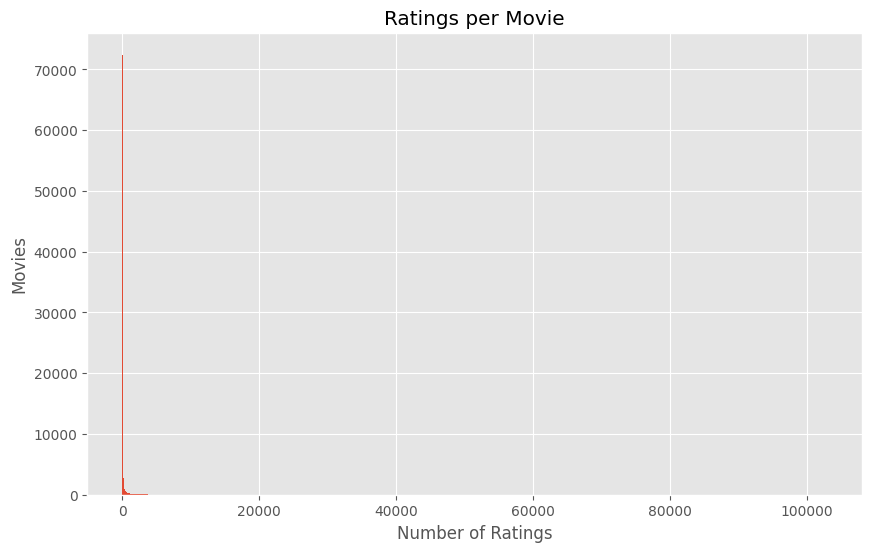

In [9]:
import matplotlib.pyplot as plt

movie_rating_counts = ratings.groupby("movieId").size()

plt.figure(figsize=(10,6))

movie_rating_counts.hist(
    bins=1000
)

plt.title("Ratings per Movie")

plt.xlabel("Number of Ratings")

plt.ylabel("Movies")

plt.show()

In [27]:
top_movies = (
    ratings
    .groupby("movieId")
    .size()
    .reset_index(name="rating_count")
)

top_movies = top_movies.merge(
    movies,
    on="movieId"
)

top_movies.sort_values(
    "rating_count",
    ascending=False
).head(20)

,movieId,rating_count,title,genres
314,318,102929,"Shawshank Redemption, The (1994)",Crime|Drama
351,356,100296,Forrest Gump (1994),Comedy|Drama|Romance|War
292,296,98409,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
2480,2571,93808,"Matrix, The (1999)",Action|Sci-Fi|Thriller
585,593,90330,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
257,260,85010,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
2867,2959,77332,Fight Club (1999),Action|Crime|Drama|Thriller
475,480,75233,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
522,527,73849,Schindler's List (1993),Drama|War
4888,4993,73122,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy


In [10]:
user_rating_counts = ratings.groupby("userId").size()

user_rating_counts.describe()

,0
count,200948.000000
mean,159.246193
std,282.025462
min,20.000000
25%,36.000000
50%,73.000000
75%,167.000000
max,33332.000000


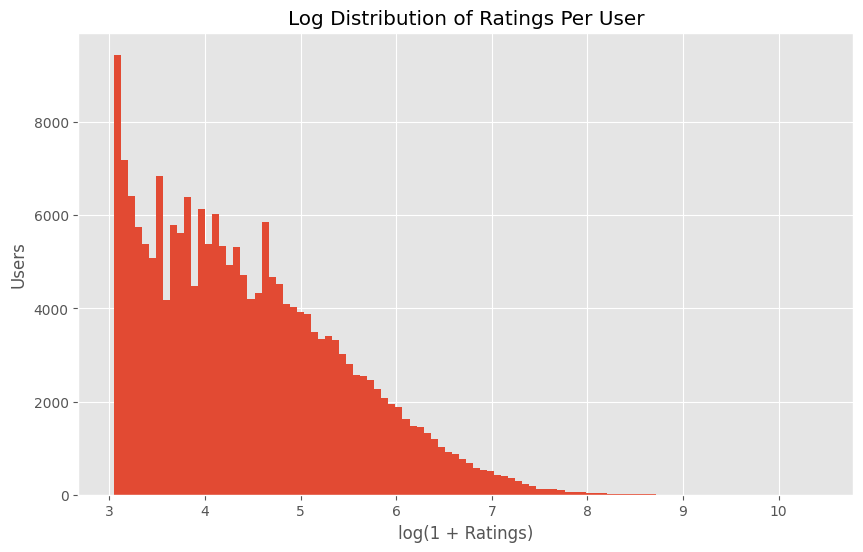

In [24]:
plt.figure(figsize=(10,6))

plt.hist(
    np.log1p(user_rating_counts),
    bins=100
)

plt.title("Log Distribution of Ratings Per User")
plt.xlabel("log(1 + Ratings)")
plt.ylabel("Users")

plt.show()

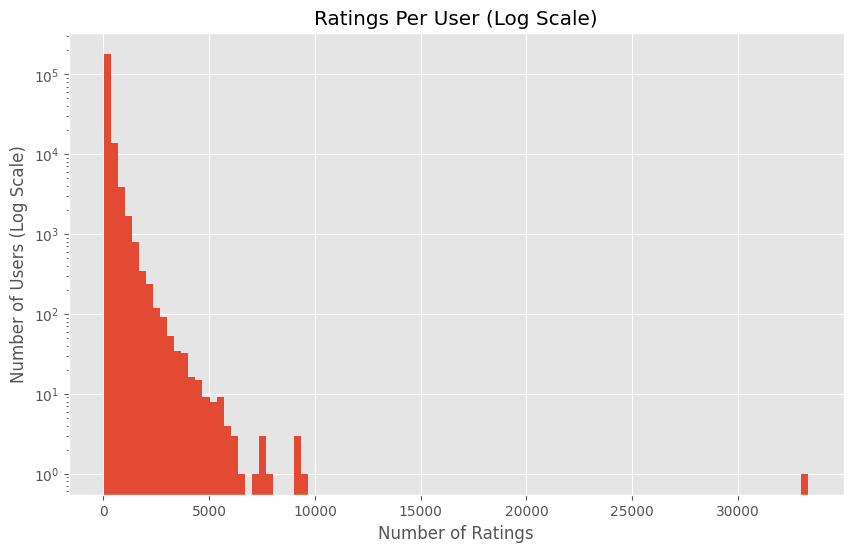

In [25]:
plt.figure(figsize=(10,6))

plt.hist(
    user_rating_counts,
    bins=100,
    log=True
)

plt.title("Ratings Per User (Log Scale)")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users (Log Scale)")

plt.show()

In [23]:
print("Maximum ratings by one user:")
print(user_rating_counts.max())

Maximum ratings by one user:
33332


In [12]:
user_rating_counts.sort_values(
    ascending=False
).head(20)

,0
userId,
175325,33332
17035,9577
55653,9178
123465,9044
171795,9016
10202,7748
198515,7594
49305,7488
22744,7372


In [17]:
genre_counts = {}

for genres in movies["genres"]:
    for genre in genres.split("|"):
        genre_counts[genre] = genre_counts.get(genre, 0) + 1

genre_counts = pd.Series(
    genre_counts
).sort_values(
    ascending=False
)

genre_counts

,0
Drama,34175
Comedy,23124
Thriller,11823
Romance,10369
Action,9668
Documentary,9363
Horror,8654
(no genres listed),7080
Crime,6976
Adventure,5402


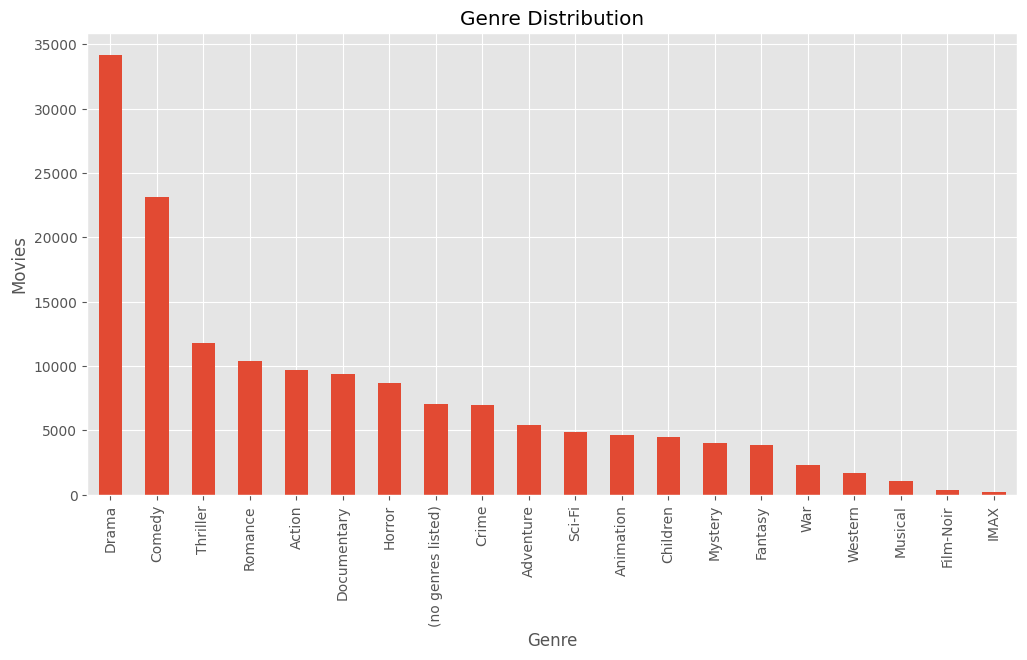

In [18]:
plt.figure(figsize=(12,6))

genre_counts.plot(kind="bar")

plt.title("Genre Distribution")

plt.xlabel("Genre")

plt.ylabel("Movies")

plt.show()

In [19]:
movie_avg_rating = (
    ratings
    .groupby("movieId")["rating"]
    .mean()
)

movie_avg_rating.describe()

,rating
count,84432.000000
mean,3.005082
std,0.801820
min,0.500000
25%,2.543478
50%,3.071429
75%,3.500000
max,5.000000


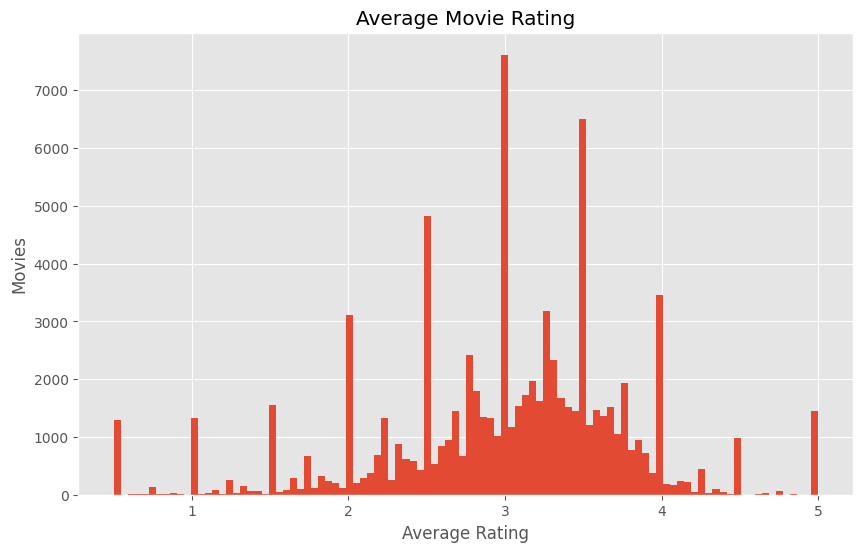

In [20]:
plt.figure(figsize=(10,6))

movie_avg_rating.hist(
    bins=100
)

plt.title("Average Movie Rating")

plt.xlabel("Average Rating")

plt.ylabel("Movies")

plt.show()

In [21]:
num_users = ratings["userId"].nunique()

num_movies = ratings["movieId"].nunique()

num_ratings = len(ratings)

sparsity = (
    1 -
    num_ratings /
    (num_users * num_movies)
)

print(f"Sparsity: {sparsity:.4%}")

Sparsity: 99.8114%


In [22]:
user_rating_counts.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,0
count,200948.000000
mean,159.246193
std,282.025462
min,20.000000
25%,36.000000
50%,73.000000
75%,167.000000
90%,364.000000
95%,571.000000
99%,1290.000000
